# Compréhension globale du projet
## 🎯 Objectif final
```
Créer un dataset d'images propre et homogène pour entraîner un modèle de reconnaissance de déchets (6 classes : cardboard, plastic, paper, glass, metal, trash).

📚 Les 14 parties de l'atelier
Partie	Sujet
0	Structure du projet
1	Exploration du dataset
2	Détection des images corrompues
3	Détection des images vides
4	Détection des différences de résolution
5	Détection des différents canaux
6	Détection des doublons
7	Détection des images mal classées
8	Analyse du déséquilibre des classes
9	Redimensionnement
10	Uniformisation des canaux
11	Mise à l'échelle des pixels
12	Découpage Train/Validation/Test
13	Data Augmentation
14	Bonus
```

# Partie 1 – Exploration du dataset
## 🎯 Objectif
```
Lire toutes les images de chaque dossier et récupérer leurs informations :

Nom, classe, format, mode

Largeur, hauteur

Écart-type des pixels (pour détecter les images vides)

Nombre de canaux

Taille du fichier
```

## 📝 Explication imagée
# C'est comme faire l'inventaire d'un entrepôt :
```
On ouvre chaque carton (dossier)

On note ce qu'il contient (nom, taille, dimensions)

On repère les cartons abîmés (images corrompues)
```

In [9]:
import os
import pandas as pd
import numpy as np
from PIL import Image, ImageStat
import warnings
warnings.filterwarnings('ignore')

# Chemins
BASE_DIR = '../data/raw'
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("✅ Bibliothèques importées")
print(f"📁 Dossier de base : {BASE_DIR}")
print(f"📂 Classes : {CLASSES}")

✅ Bibliothèques importées
📁 Dossier de base : ../data/raw
📂 Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


##  Fonction de détection d'image corrompue

In [15]:
def est_corrompue(chemin):
    try:
        with Image.open(chemin) as img:
            img.verify()
        return False
    except Exception:
        return True

In [16]:
def explorer_dataset(base_dir, classes):
    """Parcourt toutes les images et collecte leurs informations."""
    donnees = []
    
    for classe in classes:
        dossier = os.path.join(base_dir, classe)
        if not os.path.exists(dossier):
            print(f"⚠️ Dossier manquant : {dossier}")
            continue
        
        fichiers = os.listdir(dossier)
        print(f"📂 {classe} : {len(fichiers)} fichiers")
        
        for fichier in fichiers:
            chemin = os.path.join(dossier, fichier)
            
            # Ignorer les sous-dossiers
            if not os.path.isfile(chemin):
                continue
            
            # Informations de base
            info = {
                'nom': fichier,
                'classe': classe,
                'chemin': chemin,
                'taille_ko': round(os.path.getsize(chemin) / 1024, 2),
                'corrompue': False,
                'format': None,
                'mode': None,
                'largeur': None,
                'hauteur': None,
                'canaux': None,
                'ecart_type': None
            }
            
            # Vérifier si corrompue
            if est_corrompue(chemin):
                info['corrompue'] = True
                donnees.append(info)
                continue
            
            # Extraire les métadonnées
            try:
                with Image.open(chemin) as img:
                    info['format'] = img.format
                    info['mode'] = img.mode
                    info['largeur'], info['hauteur'] = img.size
                    info['canaux'] = len(img.getbands())
                    
                    # Écart-type des pixels (pour détecter images vides)
                    stat = ImageStat.Stat(img.convert('L'))
                    info['ecart_type'] = round(stat.stddev[0], 2)
            except Exception as e:
                info['corrompue'] = True
            
            donnees.append(info)
    
    return pd.DataFrame(donnees)

# Exécution
df = explorer_dataset(BASE_DIR, CLASSES)

print(f"\n✅ Exploration terminée : {len(df)} images analysées")
print(f"📊 Aperçu :")
df.head()

📂 cardboard : 169 fichiers
📂 glass : 188 fichiers
📂 metal : 149 fichiers
📂 paper : 252 fichiers
📂 plastic : 224 fichiers
📂 trash : 50 fichiers

✅ Exploration terminée : 1032 images analysées
📊 Aperçu :


,nom,classe,chemin,taille_ko,corrompue,format,mode,largeur,hauteur,canaux,ecart_type
0,cardboard1.jpg,cardboard,../data/raw\cardboard\cardboard1.jpg,16.93,False,JPEG,RGB,512.0,384.0,3.0,31.88
1,cardboard10.jpg,cardboard,../data/raw\cardboard\cardboard10.jpg,21.17,False,JPEG,RGB,512.0,384.0,3.0,38.80
2,cardboard100.jpg,cardboard,../data/raw\cardboard\cardboard100.jpg,14.54,False,JPEG,RGB,512.0,384.0,3.0,44.50
3,cardboard101.jpg,cardboard,../data/raw\cardboard\cardboard101.jpg,13.95,False,JPEG,RGB,512.0,384.0,3.0,68.56
4,cardboard102.jpg,cardboard,../data/raw\cardboard\cardboard102.jpg,17.59,False,JPEG,RGB,512.0,384.0,3.0,45.32


### Sauvegarde de l'audit

In [17]:
# Créer le dossier reports s'il n'existe pas
os.makedirs('../reports', exist_ok=True)

# Sauvegarder l'audit
df.to_csv('../reports/audit_images.csv', index=False)

print("✅ Audit sauvegardé dans '../reports/audit_images.csv'")
print(f"📊 Nombre total d'images : {len(df)}")
print(f"❌ Images corrompues : {df['corrompue'].sum()}")

✅ Audit sauvegardé dans '../reports/audit_images.csv'
📊 Nombre total d'images : 1032
❌ Images corrompues : 6


### Statistiques générales

In [18]:
print("=== STATISTIQUES GÉNÉRALES ===\n")

print(f"📊 Total d'images : {len(df)}")
print(f"❌ Images corrompues : {df['corrompue'].sum()}")

print("\n📂 Répartition par classe :")
print(df['classe'].value_counts())

print("\n🎨 Répartition par mode :")
print(df['mode'].value_counts())

print("\n📐 Répartition par nombre de canaux :")
print(df['canaux'].value_counts())

=== STATISTIQUES GÉNÉRALES ===

📊 Total d'images : 1032
❌ Images corrompues : 6

📂 Répartition par classe :
classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

🎨 Répartition par mode :
mode
RGB     1006
RGBA      18
P          2
Name: count, dtype: int64

📐 Répartition par nombre de canaux :
canaux
3.0    1006
4.0      18
1.0       2
Name: count, dtype: int64


### ✅ Vérification

In [19]:
print("=== VÉRIFICATION PARTIE 1 ===")
print(f"✅ DataFrame créé : {df.shape}")
print(f"✅ Colonnes : {list(df.columns)}")
print(f"✅ Fichier CSV sauvegardé : ../reports/audit_images.csv")

=== VÉRIFICATION PARTIE 1 ===
✅ DataFrame créé : (1032, 11)
✅ Colonnes : ['nom', 'classe', 'chemin', 'taille_ko', 'corrompue', 'format', 'mode', 'largeur', 'hauteur', 'canaux', 'ecart_type']
✅ Fichier CSV sauvegardé : ../reports/audit_images.csv


# Partie 2 – Détection des images corrompues
## 🎯 Objectif
### Isoler toutes les images qui ne peuvent pas être lues correctement par Python, pour les exclure du dataset.

**📝 Explication imagée**
C'est comme un contrôle qualité à l'entrée d'une usine :

* On ouvre chaque colis (image)

* Si le colis est abîmé (fichier corrompu), on le met de côté

* Les bons colis continuent leur chemin

* Une image corrompue = un fichier qu'on ne peut pas ouvrir ou lire correctement (fichier tronqué, mauvais format, erreur de téléchargement...).

  ### 1 – Récapitulatif des images corrompues

In [20]:
print("=== IMAGES CORROMPUES ===\n")

# Filtrer les images corrompues
images_corrompues = df[df['corrompue'] == True]

print(f"❌ Nombre d'images corrompues : {len(images_corrompues)}")
print(f"📊 Pourcentage : {len(images_corrompues)/len(df)*100:.2f}%\n")

if len(images_corrompues) > 0:
    print("Liste des images corrompues :")
    print(images_corrompues[['nom', 'classe', 'taille_ko']].to_string(index=False))
else:
    print("✅ Aucune image corrompue détectée !")

=== IMAGES CORROMPUES ===

❌ Nombre d'images corrompues : 6
📊 Pourcentage : 0.58%

Liste des images corrompues :
            nom    classe  taille_ko
cardboard83.jpg cardboard      20.40
    glass74.jpg     glass       7.02
    metal48.jpg     metal       7.09
   paper213.jpg     paper       7.12
  plastic13.jpg   plastic       5.13
     trash3.jpg     trash       8.98


### 2 – Répartition par classe

In [21]:
if len(images_corrompues) > 0:
    print("=== RÉPARTITION DES IMAGES CORROMPUES PAR CLASSE ===\n")
    
    repartition = images_corrompues.groupby('classe').size()
    
    for classe, nombre in repartition.items():
        total_classe = len(df[df['classe'] == classe])
        pourcentage = nombre / total_classe * 100
        print(f"📂 {classe:12s} : {nombre:3d} corrompues / {total_classe:4d} total ({pourcentage:.1f}%)")

=== RÉPARTITION DES IMAGES CORROMPUES PAR CLASSE ===

📂 cardboard    :   1 corrompues /  169 total (0.6%)
📂 glass        :   1 corrompues /  188 total (0.5%)
📂 metal        :   1 corrompues /  149 total (0.7%)
📂 paper        :   1 corrompues /  252 total (0.4%)
📂 plastic      :   1 corrompues /  224 total (0.4%)
📂 trash        :   1 corrompues /   50 total (2.0%)


### 3 – Création du dataset propre (sans corrompues)

In [22]:
# Dataset sans les images corrompues
df_propre = df[df['corrompue'] == False].copy()

print("=== DATASET APRÈS SUPPRESSION DES IMAGES CORROMPUES ===\n")
print(f"📊 Avant : {len(df)} images")
print(f"📊 Après : {len(df_propre)} images")
print(f"🗑️  Supprimées : {len(df) - len(df_propre)} images")
print(f"✅ Pourcentage conservé : {len(df_propre)/len(df)*100:.2f}%")

# Sauvegarder cette version
df_propre.to_csv('../reports/audit_images_sans_corrompues.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_corrompues.csv'")

=== DATASET APRÈS SUPPRESSION DES IMAGES CORROMPUES ===

📊 Avant : 1032 images
📊 Après : 1026 images
🗑️  Supprimées : 6 images
✅ Pourcentage conservé : 99.42%

💾 Sauvegardé dans '../reports/audit_images_sans_corrompues.csv'


### 4 – Visualisation 

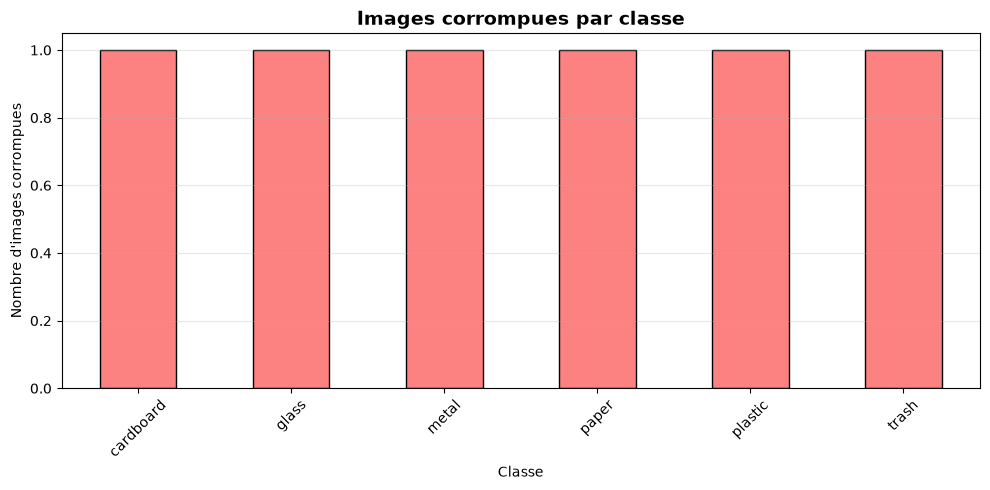

💾 Graphique sauvegardé dans '../reports/images_corrompues.png'


In [23]:
import matplotlib.pyplot as plt

if len(images_corrompues) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    repartition = images_corrompues.groupby('classe').size()
    repartition.plot(kind='bar', color='#fc8181', edgecolor='black', ax=ax)
    
    ax.set_title('Images corrompues par classe', fontsize=14, fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Nombre d\'images corrompues')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/images_corrompues.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("💾 Graphique sauvegardé dans '../reports/images_corrompues.png'")

```
Dataset original (100%)
        │
        ▼
┌───────────────────────┐
│  Images corrompues ?  │
└───────────────────────┘
        │
    ┌───┴───┐
    │       │
   OUI     NON
    │       │
    ▼       ▼
  🗑️      ✅
Supprimer  Conserver
            │
            ▼
    Dataset propre
```

### ✅ Vérification

In [24]:
print("=== VÉRIFICATION PARTIE 2 ===")
print(f"✅ Fonction de détection : est_corrompue()")
print(f"✅ Images corrompues identifiées : {len(images_corrompues)}")
print(f"✅ Dataset propre : {len(df_propre)} images conservées")
print(f"✅ Fichier sauvegardé : audit_images_sans_corrompues.csv")

=== VÉRIFICATION PARTIE 2 ===
✅ Fonction de détection : est_corrompue()
✅ Images corrompues identifiées : 6
✅ Dataset propre : 1026 images conservées
✅ Fichier sauvegardé : audit_images_sans_corrompues.csv


# Partie 3 – Détection des images vides

## 🎯 Objectif
Identifier les images qui ne contiennent **aucune information utile** : 
- Images entièrement noires
- Images entièrement blanches
- Images avec très peu de variation de pixels (unies)

## 📝 Explication imagée

C'est comme vérifier qu'une **photo n'est pas un écran noir** :
- Une image **noire** = pixels tous à 0 (aucune information)
- Une image **blanche** = pixels tous à 255 (aucune information)
- Une image **unie** = pixels presque identiques (très peu de variation)

**Comment détecter ?** On utilise l'**écart-type** des pixels :
- Écart-type proche de **0** → image vide ou unie
- Écart-type élevé → image avec du contenu

# Fonction de détection d'image vide

In [25]:
def est_vide(chemin, seuil_ecart_type=10, seuil_extremes=0.98):
    """
    Détecte si une image est vide ou quasi-vide.
    
    Paramètres:
    -----------
    chemin : str - Chemin de l'image
    seuil_ecart_type : float - Écart-type minimum pour considérer l'image comme non vide
    seuil_extremes : float - Proportion de pixels noirs/blancs pour considérer l'image comme vide
    
    Retourne:
    --------
    tuple : (est_vide, raison)
    """
    try:
        with Image.open(chemin) as img:
            # Convertir en niveaux de gris pour simplifier
            img_gris = img.convert('L')
            pixels = np.array(img_gris)
            
            # 1. Vérifier l'écart-type (variation des pixels)
            ecart_type = np.std(pixels)
            if ecart_type < seuil_ecart_type:
                return True, f"Écart-type faible ({ecart_type:.2f})"
            
            # 2. Vérifier la proportion de pixels noirs ou blancs
            total_pixels = pixels.size
            pixels_noirs = np.sum(pixels < 10) / total_pixels
            pixels_blancs = np.sum(pixels > 245) / total_pixels
            
            if pixels_noirs > seuil_extremes:
                return True, f"Image presque entièrement noire ({pixels_noirs*100:.1f}%)"
            if pixels_blancs > seuil_extremes:
                return True, f"Image presque entièrement blanche ({pixels_blancs*100:.1f}%)"
            
            return False, "OK"
    
    except Exception as e:
        return True, f"Erreur : {e}"

### Application de la détection sur le dataset

On applique la fonction `est_vide()` à toutes les images du dataset propre.

In [26]:
# Appliquer la détection sur le dataset propre
resultats_vides = df_propre['chemin'].apply(lambda x: est_vide(x))

# Extraire les résultats
df_propre['est_vide'] = resultats_vides.apply(lambda x: x[0])
df_propre['raison_vide'] = resultats_vides.apply(lambda x: x[1])

# Nombre d'images vides
nb_vides = df_propre['est_vide'].sum()

print("=== DÉTECTION DES IMAGES VIDES ===\n")
print(f"📊 Total d'images analysées : {len(df_propre)}")
print(f"⚠️  Images vides détectées : {nb_vides}")
print(f"✅ Images valides : {len(df_propre) - nb_vides}")
print(f"📈 Pourcentage d'images vides : {nb_vides/len(df_propre)*100:.2f}%")

=== DÉTECTION DES IMAGES VIDES ===

📊 Total d'images analysées : 1026
⚠️  Images vides détectées : 10
✅ Images valides : 1016
📈 Pourcentage d'images vides : 0.97%


### Détail des images vides

Affichons la liste des images considérées comme vides avec la raison.

In [27]:
images_vides = df_propre[df_propre['est_vide'] == True]

if len(images_vides) > 0:
    print("=== DÉTAIL DES IMAGES VIDES ===\n")
    print(images_vides[['nom', 'classe', 'ecart_type', 'raison_vide']].to_string(index=False))
    
    print("\n📊 Répartition par classe :")
    print(images_vides.groupby('classe').size())
else:
    print("✅ Aucune image vide détectée !")

=== DÉTAIL DES IMAGES VIDES ===

                      nom    classe  ecart_type              raison_vide
image-blanche-512x384.jpg cardboard        1.13 Écart-type faible (1.13)
             glass178.jpg     glass        9.75 Écart-type faible (9.75)
  image-noire-512x384.png     glass        0.00 Écart-type faible (0.00)
image-blanche-512x384.jpg     metal        1.13 Écart-type faible (1.13)
  image-noire-512x384.png     metal        0.00 Écart-type faible (0.00)
            plastic12.jpg   plastic        9.26 Écart-type faible (9.26)
           plastic147.jpg   plastic        8.41 Écart-type faible (8.41)
           plastic150.jpg   plastic        7.49 Écart-type faible (7.49)
             plastic2.jpg   plastic        8.59 Écart-type faible (8.59)
             plastic3.jpg   plastic        7.98 Écart-type faible (7.98)

📊 Répartition par classe :
classe
cardboard    1
glass        2
metal        2
plastic      5
dtype: int64


### Visualisation (optionnel)

On peut afficher quelques images vides pour vérifier visuellement.

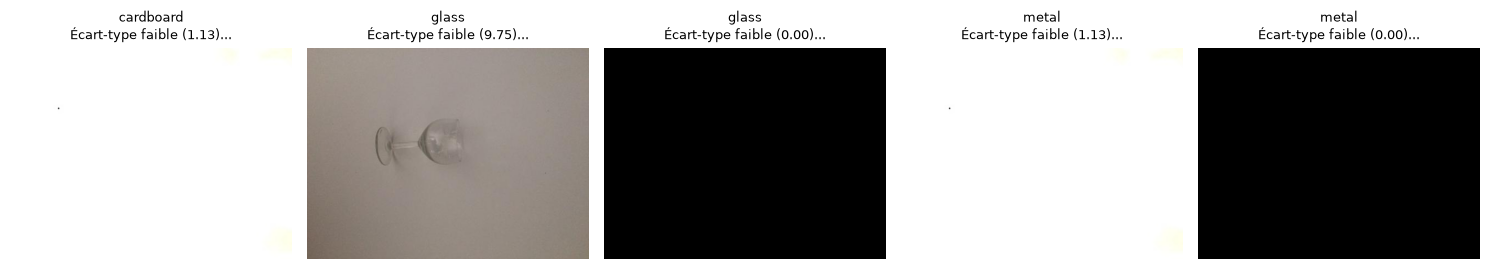

💾 Graphique sauvegardé dans '../reports/images_vides.png'


In [28]:
import matplotlib.pyplot as plt

if len(images_vides) > 0:
    # Afficher jusqu'à 5 images vides
    nb_a_afficher = min(5, len(images_vides))
    fig, axes = plt.subplots(1, nb_a_afficher, figsize=(15, 4))
    
    if nb_a_afficher == 1:
        axes = [axes]
    
    for i, (idx, row) in enumerate(images_vides.head(nb_a_afficher).iterrows()):
        try:
            img = Image.open(row['chemin'])
            axes[i].imshow(img)
            axes[i].set_title(f"{row['classe']}\n{row['raison_vide'][:30]}...", fontsize=9)
            axes[i].axis('off')
        except:
            axes[i].text(0.5, 0.5, 'Erreur', ha='center', va='center')
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('../reports/images_vides.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Graphique sauvegardé dans '../reports/images_vides.png'")

### Création du dataset sans images vides

On retire les images vides du dataset pour ne garder que les images utiles.

In [29]:
# Dataset sans les images vides
df_sans_vides = df_propre[df_propre['est_vide'] == False].copy()

print("=== DATASET APRÈS SUPPRESSION DES IMAGES VIDES ===\n")
print(f"📊 Avant : {len(df_propre)} images")
print(f"📊 Après : {len(df_sans_vides)} images")
print(f"🗑️  Supprimées : {len(df_propre) - len(df_sans_vides)} images")

# Sauvegarder
df_sans_vides.to_csv('../reports/audit_images_sans_vides.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_vides.csv'")

=== DATASET APRÈS SUPPRESSION DES IMAGES VIDES ===

📊 Avant : 1026 images
📊 Après : 1016 images
🗑️  Supprimées : 10 images

💾 Sauvegardé dans '../reports/audit_images_sans_vides.csv'


In [30]:
print("=== VÉRIFICATION PARTIE 3 ===")
print(f"✅ Fonction de détection : est_vide()")
print(f"✅ Images vides identifiées : {nb_vides}")
print(f"✅ Dataset final : {len(df_sans_vides)} images")
print(f"✅ Fichier sauvegardé : audit_images_sans_vides.csv")

=== VÉRIFICATION PARTIE 3 ===
✅ Fonction de détection : est_vide()
✅ Images vides identifiées : 10
✅ Dataset final : 1016 images
✅ Fichier sauvegardé : audit_images_sans_vides.csv


# Partie 4 – Détection des différences de résolution

## 🎯 Objectif
Analyser les **dimensions** (largeur × hauteur) de toutes les images pour :
1. Déterminer la résolution minimale, maximale et les plus fréquentes
2. Identifier les images trop petites (< 64 × 64 pixels)

## 📝 Explication imagée

C'est comme mesurer la **taille des vêtements** dans un lot :
- Certains sont trop petits (XS)
- D'autres sont immenses (XXL)
- La plupart sont standards (M)

**Problème** : Un modèle de Deep Learning a besoin d'images **de même taille** pour apprendre correctement. On doit donc détecter les tailles pour ensuite les uniformiser.

In [31]:
# Créer une colonne "résolution" (largeur x hauteur)
df_sans_vides['resolution'] = df_sans_vides['largeur'].astype(str) + 'x' + df_sans_vides['hauteur'].astype(str)

# Statistiques générales
print("=== STATISTIQUES DES RÉSOLUTIONS ===\n")

print(f"📐 Largeur minimale  : {df_sans_vides['largeur'].min()} px")
print(f"📐 Largeur maximale  : {df_sans_vides['largeur'].max()} px")
print(f"📐 Hauteur minimale  : {df_sans_vides['hauteur'].min()} px")
print(f"📐 Hauteur maximale  : {df_sans_vides['hauteur'].max()} px")

print(f"\n📊 Largeur moyenne : {df_sans_vides['largeur'].mean():.0f} px")
print(f"📊 Hauteur moyenne : {df_sans_vides['hauteur'].mean():.0f} px")

=== STATISTIQUES DES RÉSOLUTIONS ===

📐 Largeur minimale  : 32.0 px
📐 Largeur maximale  : 512.0 px
📐 Hauteur minimale  : 32.0 px
📐 Hauteur maximale  : 384.0 px

📊 Largeur moyenne : 506 px
📊 Hauteur moyenne : 380 px


### Résolutions les plus fréquentes

On compte combien d'images partagent la même résolution.

In [32]:
print("=== TOP 10 DES RÉSOLUTIONS LES PLUS FRÉQUENTES ===\n")

top_resolutions = df_sans_vides['resolution'].value_counts().head(10)

for resolution, nombre in top_resolutions.items():
    pourcentage = nombre / len(df_sans_vides) * 100
    print(f"📐 {resolution:15s} : {nombre:4d} images ({pourcentage:5.2f}%)")

=== TOP 10 DES RÉSOLUTIONS LES PLUS FRÉQUENTES ===

📐 512.0x384.0     : 1003 images (98.72%)
📐 32.0x32.0       :    5 images ( 0.49%)
📐 48.0x32.0       :    4 images ( 0.39%)
📐 40.0x40.0       :    4 images ( 0.39%)


### Détection des images trop petites

**Contrainte** : Une image doit avoir au minimum **64 × 64 pixels**.

Une image plus petite que 64×64 est considérée comme **trop petite** pour être utile.

In [33]:
# Taille minimale acceptée
TAILLE_MIN = 64

# Détecter les images trop petites
df_sans_vides['trop_petite'] = (
    (df_sans_vides['largeur'] < TAILLE_MIN) | 
    (df_sans_vides['hauteur'] < TAILLE_MIN)
)

images_trop_petites = df_sans_vides[df_sans_vides['trop_petite'] == True]

print("=== IMAGES TROP PETITES ===\n")
print(f"📏 Taille minimale acceptée : {TAILLE_MIN}×{TAILLE_MIN} px")
print(f"⚠️  Images trop petites : {len(images_trop_petites)}")
print(f"📈 Pourcentage : {len(images_trop_petites)/len(df_sans_vides)*100:.2f}%")

if len(images_trop_petites) > 0:
    print("\nDétail des images trop petites :")
    print(images_trop_petites[['nom', 'classe', 'largeur', 'hauteur']].head(10).to_string(index=False))

=== IMAGES TROP PETITES ===

📏 Taille minimale acceptée : 64×64 px
⚠️  Images trop petites : 13
📈 Pourcentage : 1.28%

Détail des images trop petites :
             nom    classe  largeur  hauteur
cardboard117.jpg cardboard     48.0     32.0
 cardboard22.jpg cardboard     32.0     32.0
 cardboard70.jpg cardboard     40.0     40.0
    glass100.jpg     glass     40.0     40.0
     glass15.jpg     glass     48.0     32.0
     glass21.jpg     glass     32.0     32.0
     glass23.jpg     glass     32.0     32.0
    metal121.jpg     metal     48.0     32.0
      metal2.jpg     metal     32.0     32.0
     metal26.jpg     metal     40.0     40.0


### Visualisation des résolutions

Histogramme des largeurs et hauteurs pour voir la distribution.

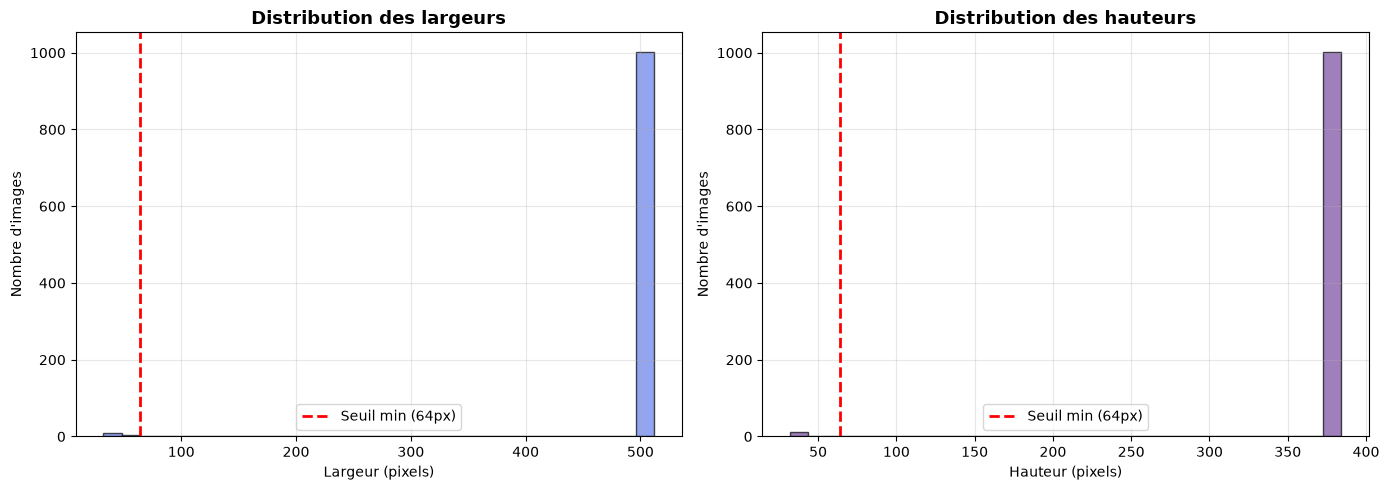

💾 Graphique sauvegardé dans '../reports/distribution_resolutions.png'


In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des largeurs
axes[0].hist(df_sans_vides['largeur'], bins=30, color='#667eea', edgecolor='black', alpha=0.7)
axes[0].axvline(x=TAILLE_MIN, color='red', linestyle='--', linewidth=2, label=f'Seuil min ({TAILLE_MIN}px)')
axes[0].set_title('Distribution des largeurs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Largeur (pixels)')
axes[0].set_ylabel('Nombre d\'images')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des hauteurs
axes[1].hist(df_sans_vides['hauteur'], bins=30, color='#764ba2', edgecolor='black', alpha=0.7)
axes[1].axvline(x=TAILLE_MIN, color='red', linestyle='--', linewidth=2, label=f'Seuil min ({TAILLE_MIN}px)')
axes[1].set_title('Distribution des hauteurs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hauteur (pixels)')
axes[1].set_ylabel('Nombre d\'images')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/distribution_resolutions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/distribution_resolutions.png'")

### Dataset final sans images trop petites

On retire les images trop petites pour ne garder que celles exploitables.

In [36]:
# Dataset sans les images trop petites
df_sans_petites = df_sans_vides[df_sans_vides['trop_petite'] == False].copy()

print("=== DATASET APRÈS SUPPRESSION DES IMAGES TROP PETITES ===\n")
print(f"📊 Avant : {len(df_sans_vides)} images")
print(f"📊 Après : {len(df_sans_petites)} images")
print(f"🗑️  Supprimées : {len(df_sans_vides) - len(df_sans_petites)} images")

# Sauvegarder
df_sans_petites.to_csv('../reports/audit_images_sans_petites.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_petites.csv'")

=== DATASET APRÈS SUPPRESSION DES IMAGES TROP PETITES ===

📊 Avant : 1016 images
📊 Après : 1003 images
🗑️  Supprimées : 13 images

💾 Sauvegardé dans '../reports/audit_images_sans_petites.csv'


In [37]:
print("=== VÉRIFICATION PARTIE 4 ===")
print(f"✅ Résolution min : {df_sans_petites['largeur'].min()}×{df_sans_petites['hauteur'].min()}")
print(f"✅ Résolution max : {df_sans_petites['largeur'].max()}×{df_sans_petites['hauteur'].max()}")
print(f"✅ Images trop petites supprimées : {len(images_trop_petites)}")
print(f"✅ Dataset final : {len(df_sans_petites)} images")

=== VÉRIFICATION PARTIE 4 ===
✅ Résolution min : 512.0×384.0
✅ Résolution max : 512.0×384.0
✅ Images trop petites supprimées : 13
✅ Dataset final : 1003 images
